# 

# Intro to Scikit-Learn - Regression

From: [Kaggle Temperature-Salinity + Geodata](https://www.kaggle.com/code/angelosorge/temperature-salinity-geodata)

**BINDA Raphaël, HNEINI Ola, WAHARTE Mathieu**  
**APP5 - 2026**

## Regression

### Context

The CalCOFI data set represents the world’s longest (1949-present) and most complete (more than 50,000 sampling stations) oceanographic and larval fish data time series. The physical, chemical, and biological data collected at regular time and space intervals help document climatic cycles in the California Current and a range of biological responses to them. CalCOFI research drew world attention to the biological response to the dramatic Pacific warming event in 1957-58 and introduced the term “El Niño” into the scientific literature.

CalCOFI conducts quarterly cruises off southern and central California, collecting a suite of hydrographic and biological data on the station and underway. Data collected at depths down to 500 m include temperature, salinity, oxygen, phosphate, silicate, nitrate and nitrite, chlorophyll, transmissometer, PAR, C14 primary productivity, phytoplankton biodiversity, zooplankton biomass, and zooplankton biodiversity.

### Scope

We would like to know how we could predict the temperature of the water based on the salinity and the depth, as well as possibly other available features.

In [2]:
%pip install plotly seaborn tqdm

Note: you may need to restart the kernel to use updated packages.


In [3]:
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly
import plotly.express as px
import seaborn as sns
import sklearn
from sklearn import datasets, decomposition, metrics, preprocessing, utils
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from tqdm.notebook import tqdm

### Data

[Main Website: CalCOFI](https://calcofi.com/)

[Bottle-Dataset](https://new.data.calcofi.com/index.php/database/calcofi-database/bottle-field-descriptions)

[Cast-Dataset](https://new.data.calcofi.com/index.php/database/calcofi-database/cast-table-column-descriptions)

In [4]:
%config InlineBackend.figure_format="retina"  # For high DPI display

sns.set_style("darkgrid")
sns.set_context("notebook")

plotly.offline.init_notebook_mode(connected=True)

tqdm.pandas()

print(sklearn.__version__)  # Version tested on sklearn.__version__ == 1.5.x

1.7.0


### Utility Functions

In [5]:
def pprint_var(**kwargs):
    for k, v in kwargs.items():
        print(f"{k} = {v:.4g}")

#### Data loading

In [6]:
DATA = Path("./Ocean/data")    # Change to your data folder
assert DATA.exists()

In [7]:
bottle_raw_df = pd.read_csv(DATA / "bottle.csv", low_memory=False)

In [8]:
bottle_info_df = pd.read_csv(
    DATA / "Bottle Field Descriptions.csv",
    encoding="cp1252",
).drop(columns=["Unnamed: 3"])

In [9]:
bottle_info_df[bottle_info_df["Field Name"] == "STheta"]

,Field Name,Units,Description
8,STheta,kilograms per cubic meter,"Potential Density (Sigma Theta), Kg/M³"


In [10]:
with pd.option_context('display.max_rows', None):
  display(bottle_info_df)

,Field Name,Units,Description
0,Cst_Cnt,n.a.,"Cast Count - All CalCOFI casts ever conducted,..."
1,Btl_Cnt,n.a.,Bottle Count - All CalCOFI bottles ever sample...
2,Sta_ID,n.a.,Line and Station [Line] [Station]
3,Depth_ID,n.a.,Uses the Cast_ID prefix ([Century]-[Year][Mont...
4,Depthm,meters,Bottle depth in meters
5,T_degC,degrees Celsius,Water temperature in degrees Celsius
6,Salnty,Practical Salinity Scale,Salinity (Practical Salinity Scale 1978)
7,O2ml_L,milliliters per liter,Milliliters oxygen per liter of seawater
8,STheta,kilograms per cubic meter,"Potential Density (Sigma Theta), Kg/M³"
9,O2Sat,percent saturation,Oxygen percent saturation


In [11]:
bottle_df = bottle_raw_df.iloc[:, [0, 4, 5, 6, 7, 8]].copy()
del bottle_raw_df
bottle_df

,Cst_Cnt,Depthm,T_degC,Salnty,O2ml_L,STheta
0,1,0,10.500,33.4400,NaN,25.64900
1,1,8,10.460,33.4400,NaN,25.65600
2,1,10,10.460,33.4370,NaN,25.65400
3,1,19,10.450,33.4200,NaN,25.64300
4,1,20,10.450,33.4210,NaN,25.64300
...,...,...,...,...,...,...
864858,34404,0,18.744,33.4083,5.805,23.87055
864859,34404,2,18.744,33.4083,5.805,23.87072
864860,34404,5,18.692,33.4150,5.796,23.88911
864861,34404,10,18.161,33.4062,5.816,24.01426


In [12]:
bottle_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 864863 entries, 0 to 864862
Data columns (total 6 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Cst_Cnt  864863 non-null  int64  
 1   Depthm   864863 non-null  int64  
 2   T_degC   853900 non-null  float64
 3   Salnty   817509 non-null  float64
 4   O2ml_L   696201 non-null  float64
 5   STheta   812174 non-null  float64
dtypes: float64(4), int64(2)
memory usage: 39.6 MB


#### Cleaning

Remove the NaN values

In [13]:
dims_before = bottle_df.shape[0]
bottle_df = bottle_df.dropna()
dims_after = bottle_df.shape[0]
print(f"On a enlevé {dims_before - dims_after} lignes avec des valeurs NaN. Soit {100 * (dims_before - dims_after) / dims_before:.2f}% du dataset.")

On a enlevé 203595 lignes avec des valeurs NaN. Soit 23.54% du dataset.


### Data Analysis

#### Plot Correlation Matrix with Seaborn

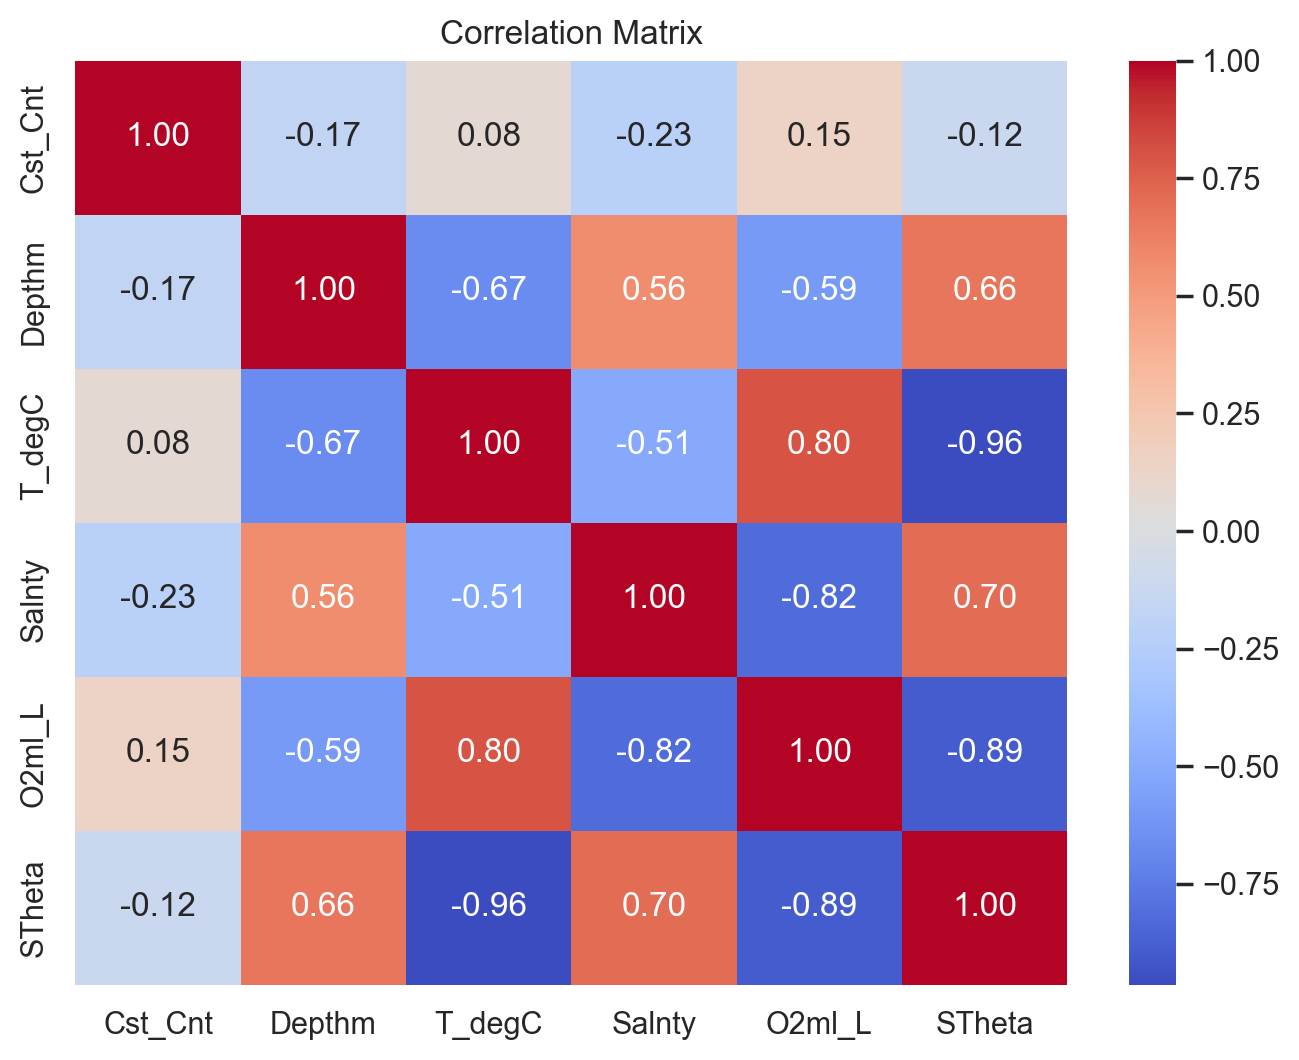

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(bottle_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Déjà on observe que la diagonale est composée de 1, ce qui est normal car chaque variable est parfaitement corrélée avec elle-même.  
&nbsp;  
On remarque pluseurs corrélations inverses (par ordre décroissant):  
- La température et la densité (-0.96 $\simeq$ -1), plus l'eau est chaude, moins elle est dense.
- La quantité d'oxygène dissous et la densité (-0.89), plus l'eau est dense, moins elle contient d'oxygène dissous.
- La salinité et la quantité d'oxygène dissous (-0.82), plus l'eau est salée, moins elle contient d'oxygène dissous.
- Température et profondeur (-0.67), plus on descend en profondeur, plus l'eau est froide.
- La quantité d'oxygène dissous et profondeur (-0.59), plus on descend en profondeur, moins l'eau contient d'oxygène dissous.
- Salinité et température (-0.52), plus l'eau est salée, plus elle est froide.
&nbsp;  
&nbsp;  

On remarque aussi des corrélations positives (par ordre décroissant):
- Température et la quantité d'oxygène dissous (0.80), plus l'eau est chaude, plus elle contient d'oxygène dissous.
- Salinité et densité (0.70), plus l'eau est salée, plus elle est dense.
- Densité et profondeur (0.66), plus on descend en profondeur, plus l'eau est dense.
- Salinité et profondeur (0.56), plus on descend en profondeur, plus l'eau est salée.

&nbsp;  

On en conclut que ces features sont très liées entre elles, et qu'il faudra faire attention à la **multicolinéarité** lors de la régression.

#### Correlation Plots

Select from the correlation matrix the 4 features involved in the most correlated pairs and plot their relationship.

C:\Users\mathi\AppData\Local\Temp\ipykernel_63384\4137964604.py:20: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\mathi\AppData\Local\Temp\ipykernel_63384\4137964604.py:20: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\mathi\AppData\Local\Temp\ipykernel_63384\4137964604.py:20: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\mathi\AppData\Local\Temp\ipykernel_63384\4137964604.py:20: FutureWarning:

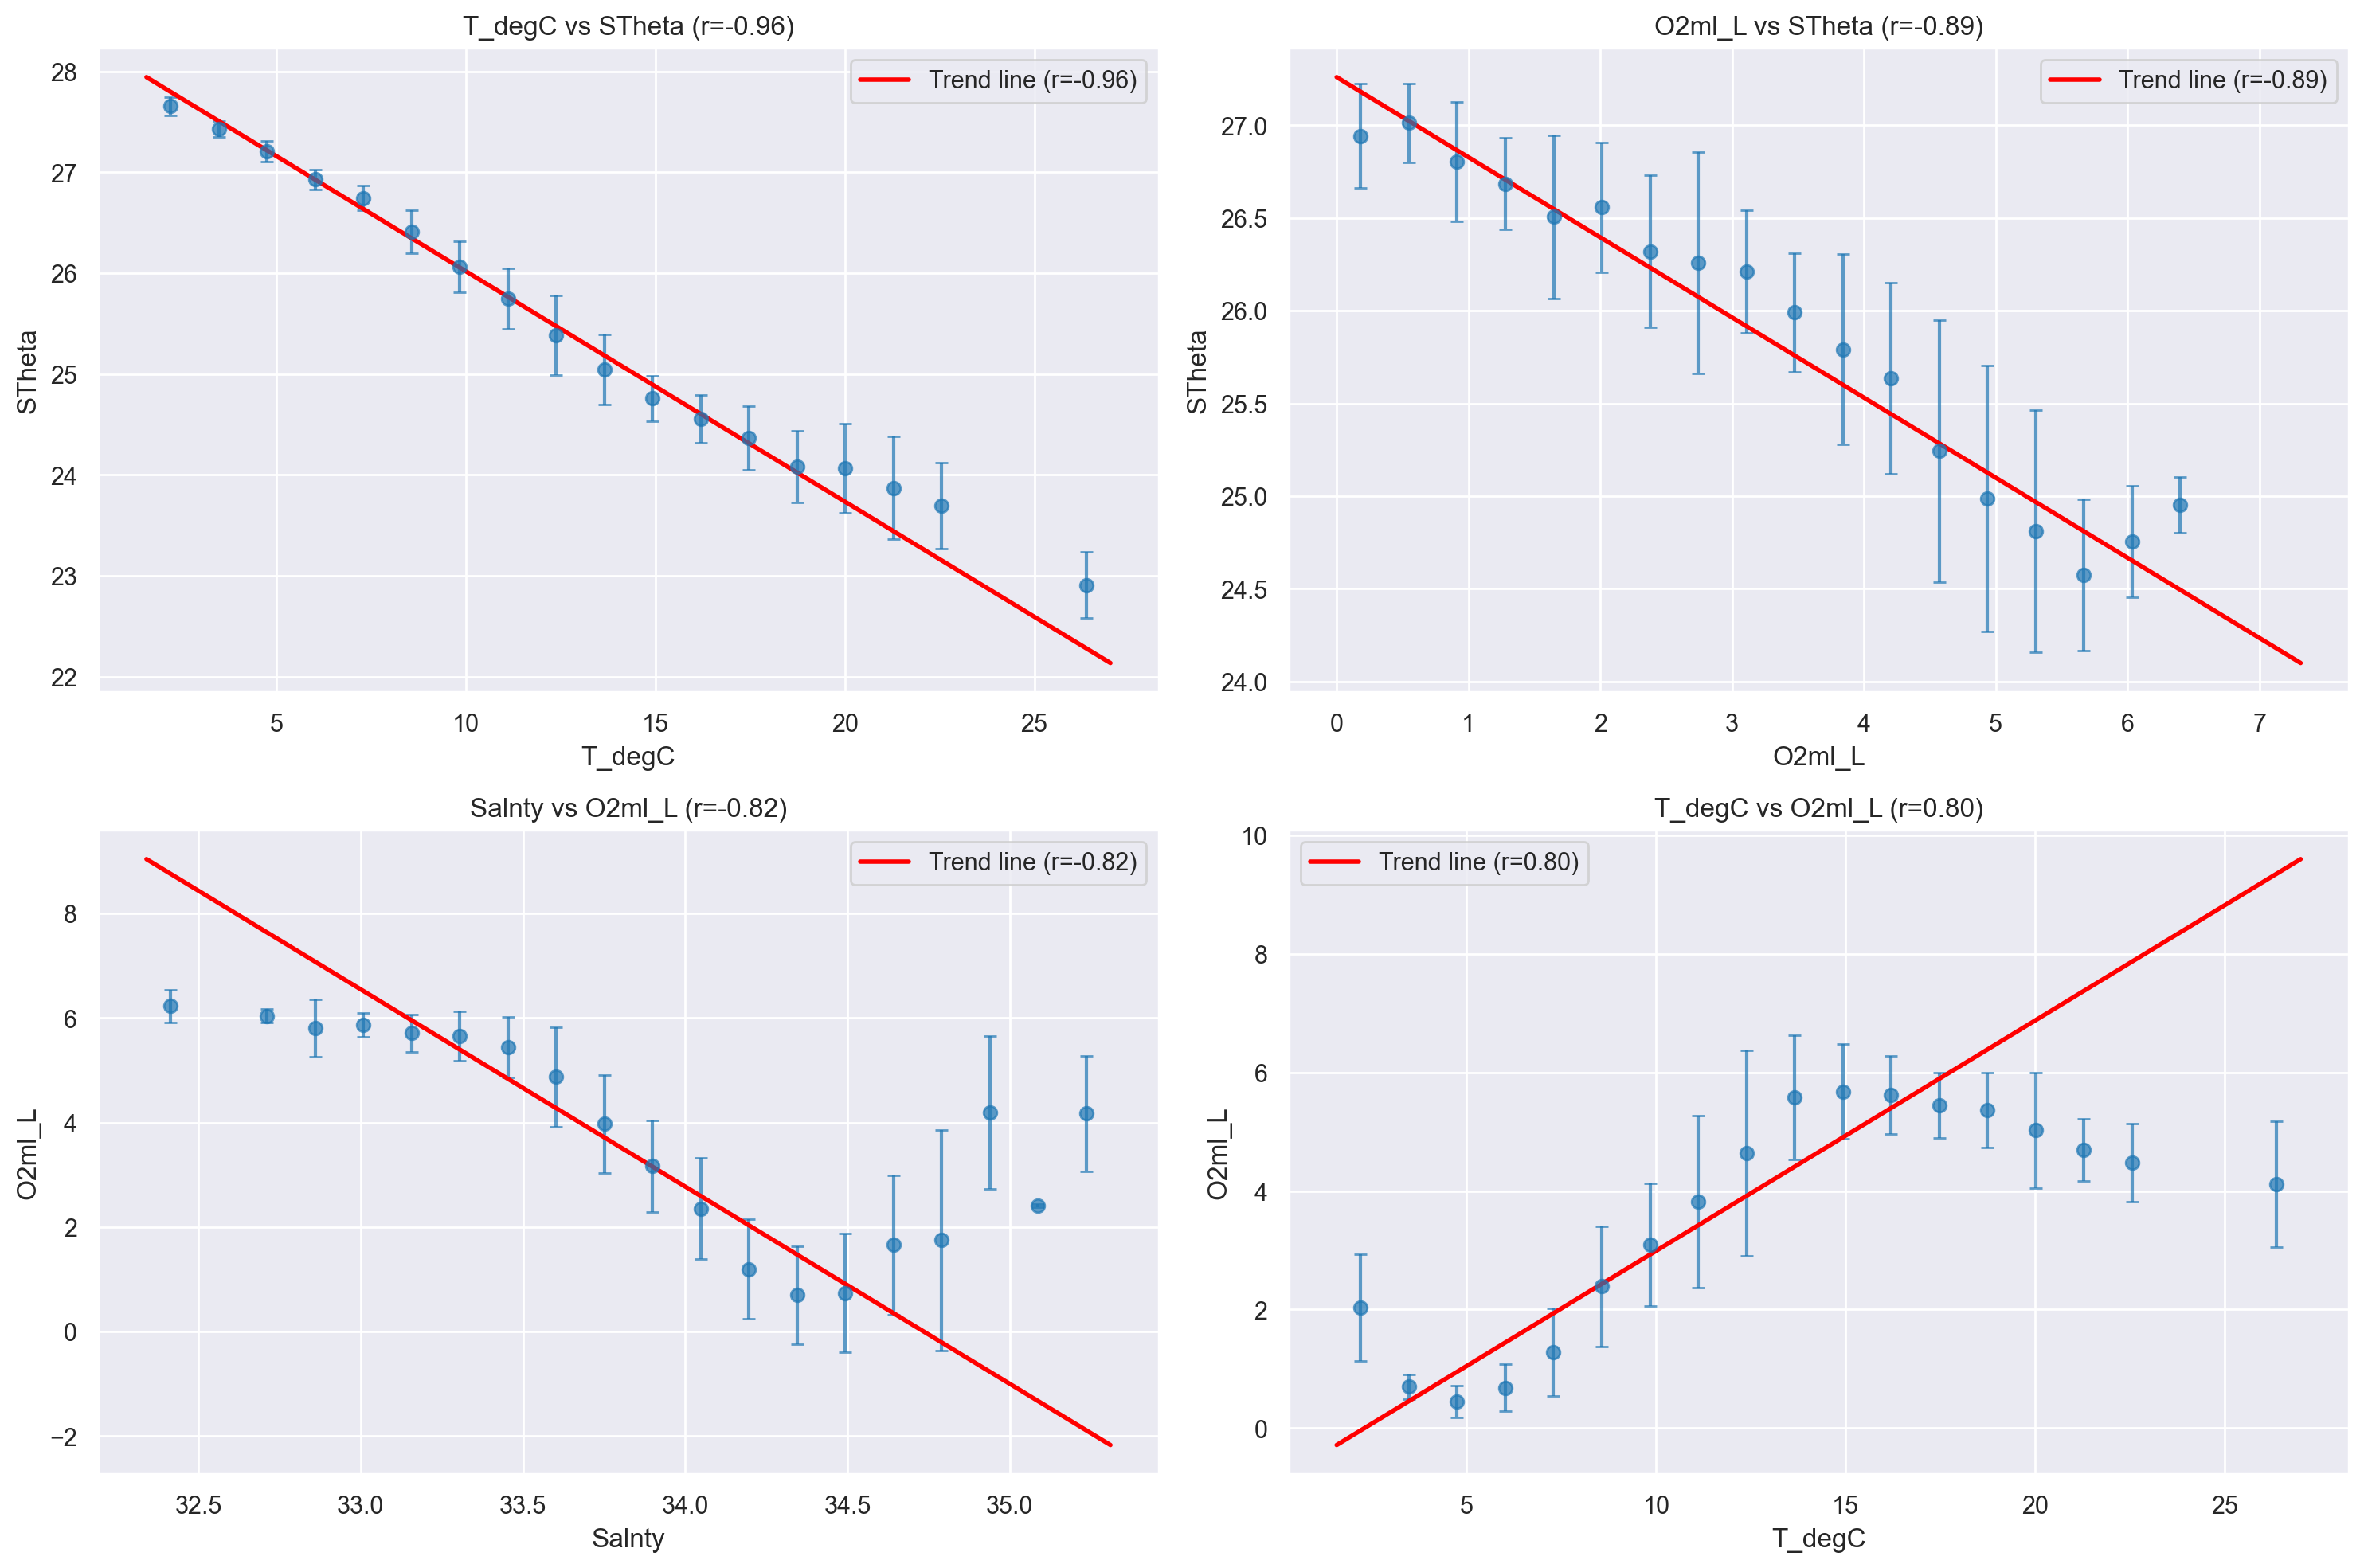

In [15]:
# Get correlation matrix and find the most correlated pairs
corr_matrix = bottle_df.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

most_correlated_pairs = upper_tri.stack().sort_values(ascending=False) # type: ignore

# Get top 4 pairs (excluding Cst_Cnt as it's just an index)
top_pairs = [(idx[0], idx[1], bottle_df.corr().loc[idx[0], idx[1]]) 
       for idx in most_correlated_pairs.head(4).index 
       if 'Cst_Cnt' not in idx][:4]

# manual_pairs = [("T_degC", "STheta", -0.96), ("STheta", "O2ml_L", -0.89), ("O2ml_L", "Salnty", -0.82), ("T_degC", "O2ml_L", 0.80)]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, (x_var, y_var, corr) in enumerate(top_pairs):
  sample_df = bottle_df.sample(n=1000, random_state=42)
  x_binned = pd.cut(sample_df[x_var], bins=20)
  grouped = sample_df.groupby(x_binned)[y_var].agg(['mean', 'std'])
  grouped = grouped.dropna()
  x_centers = [interval.mid for interval in grouped.index]
  axes[i].errorbar(x_centers, grouped['mean'], yerr=grouped['std'], fmt='o', capsize=3, alpha=0.7)
  axes[i].set_xlabel(x_var)
  axes[i].set_ylabel(y_var)
  axes[i].set_title(f"{x_var} vs {y_var} (r={corr:.2f})")
  axes[i].grid(True)

  # trend line
  z = np.polyfit(sample_df[x_var], sample_df[y_var], 1)
  p = np.poly1d(z)
  x_line = np.linspace(sample_df[x_var].min(), sample_df[x_var].max(), 100)
  axes[i].plot(x_line, p(x_line), 'r-', linewidth=2, label=f'Trend line (r={corr:.2f})')
  axes[i].legend()

plt.grid(True)
plt.tight_layout()
plt.show()

#### Depth – Temperature – Salinity

*   The Temperature as a function of the Depth

*   The Salinity as a function of the Depth

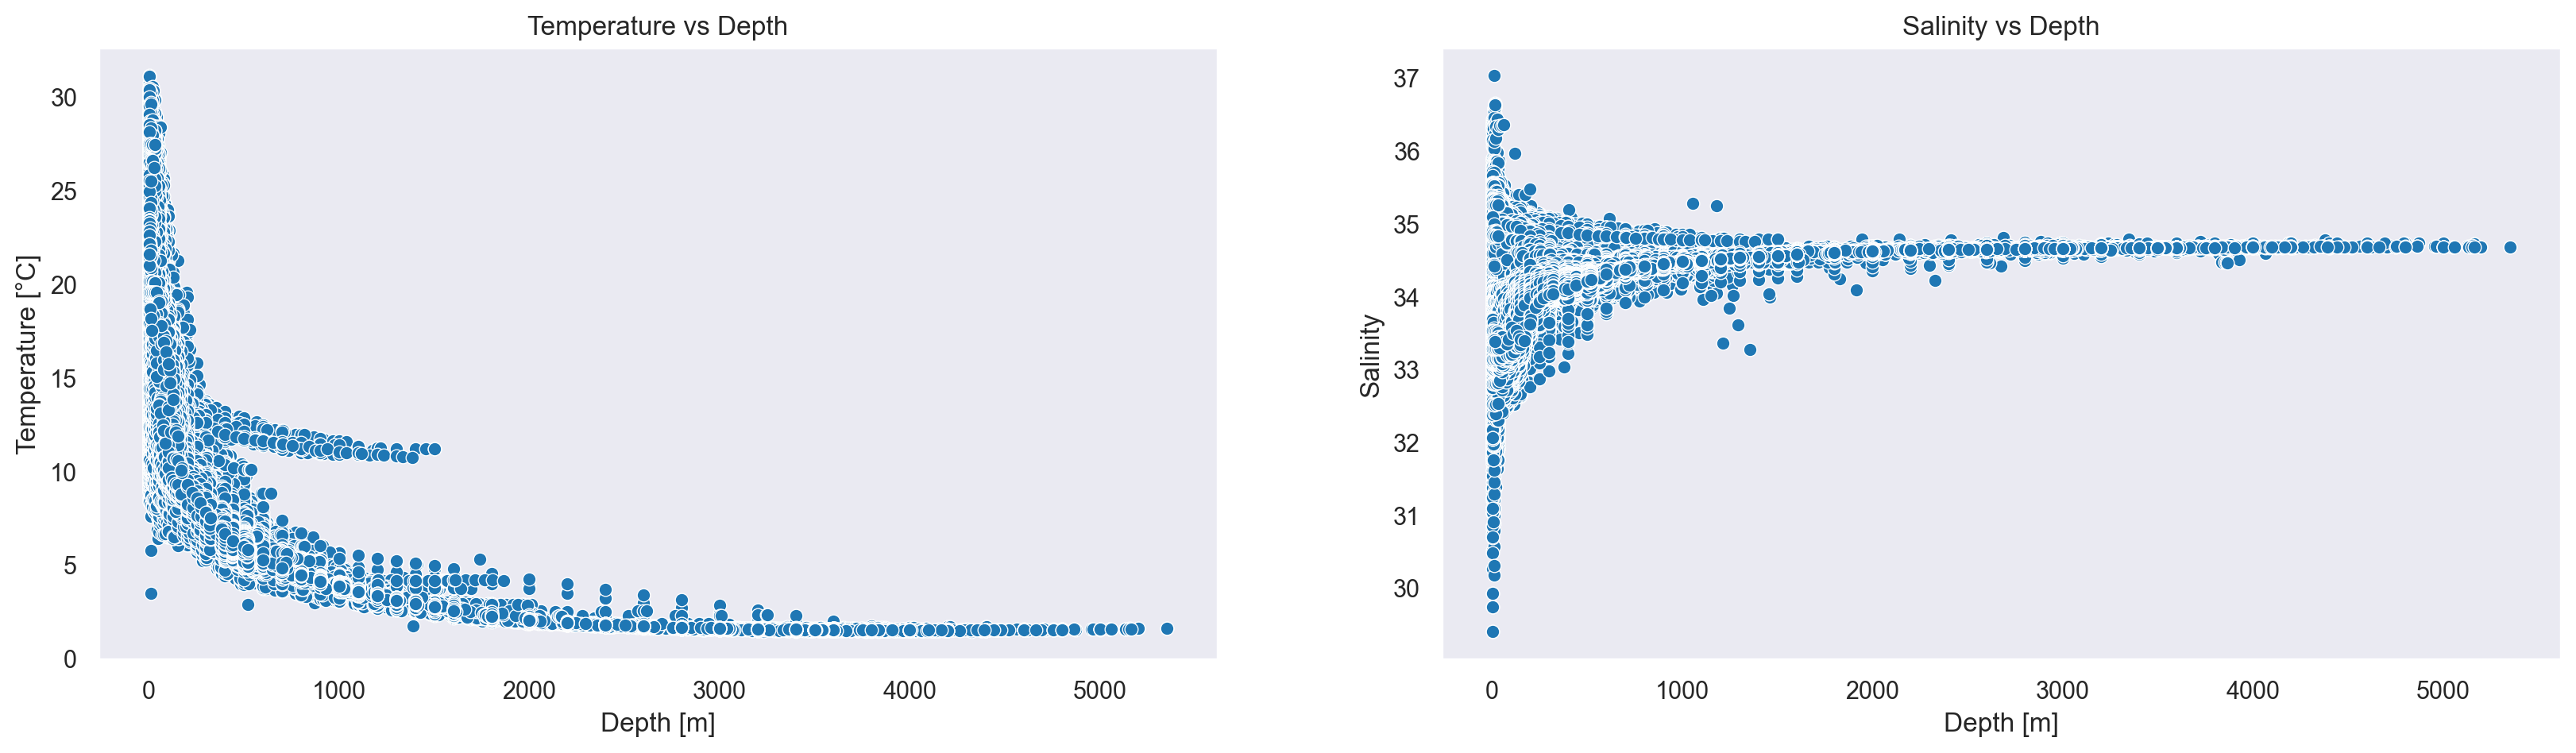

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5))
g1 = sns.scatterplot(data=bottle_df, x="Depthm", y="T_degC", ax=ax[0])
ax[0].set(
    xlabel="Depth [m]",
    ylabel="Temperature [°C]",
    title="Temperature vs Depth",
)
ax[0].grid()
g2 = sns.scatterplot(data=bottle_df, x="Depthm", y="Salnty", ax=ax[1])
ax[1].set(xlabel="Depth [m]", ylabel="Salinity", title="Salinity vs Depth")
ax[1].grid()

As we can see from the image above, temperature and salinity trace a hyperbolic trend as depth changes:

- In the first plot, some points in the upper part of the image show a different trend from the rest of the graph. It is an unexpected behavior because, for instance, at around 1000 m depth, the expected temperature is around 5°C, but we also find temperatures between 10°C and 15°C (https://www.windows2universe.org/earth/Water/temp.html).

- In the second plot, the points converge asymptotically from both high and low salinity values. It means salinity increases with depth in some ocean areas and vice versa.

Suppose we isolate data points with salinity values in the range above the salinity values in the deepest ocean area. In that case, we observe an alternative trend highlighted in the Temperature-Depth graph.

In [17]:
max_depth_salnty = bottle_df.loc[bottle_df.Depthm.idxmax()].Salnty
max_depth_salnty += 0.1  # Margin to stay on the upper side of the asymptote
pprint_var(max_depth_salnty=max_depth_salnty)

bottle_hi_salt_df = bottle_df[bottle_df.Salnty > max_depth_salnty]
bottle_hi_salt_df   # with max_depth_salnty = 34.85: 6818 rows × 6 columns

max_depth_salnty = 34.78


,Cst_Cnt,Depthm,T_degC,Salnty,O2ml_L,STheta
9204,305,1180,3.10,35.250,0.49,28.083
40328,1303,854,4.01,34.930,1.85,27.736
41497,1339,415,7.80,35.090,0.28,27.381
55857,1809,2142,1.98,34.790,1.85,27.817
55862,1809,2688,1.73,34.810,2.47,27.855
...,...,...,...,...,...,...
479617,19189,11,27.49,34.839,4.62,22.442
479618,19189,20,27.47,34.838,4.59,22.449
479619,19189,30,27.45,34.837,4.55,22.455
479620,19189,31,27.45,34.837,4.55,22.455


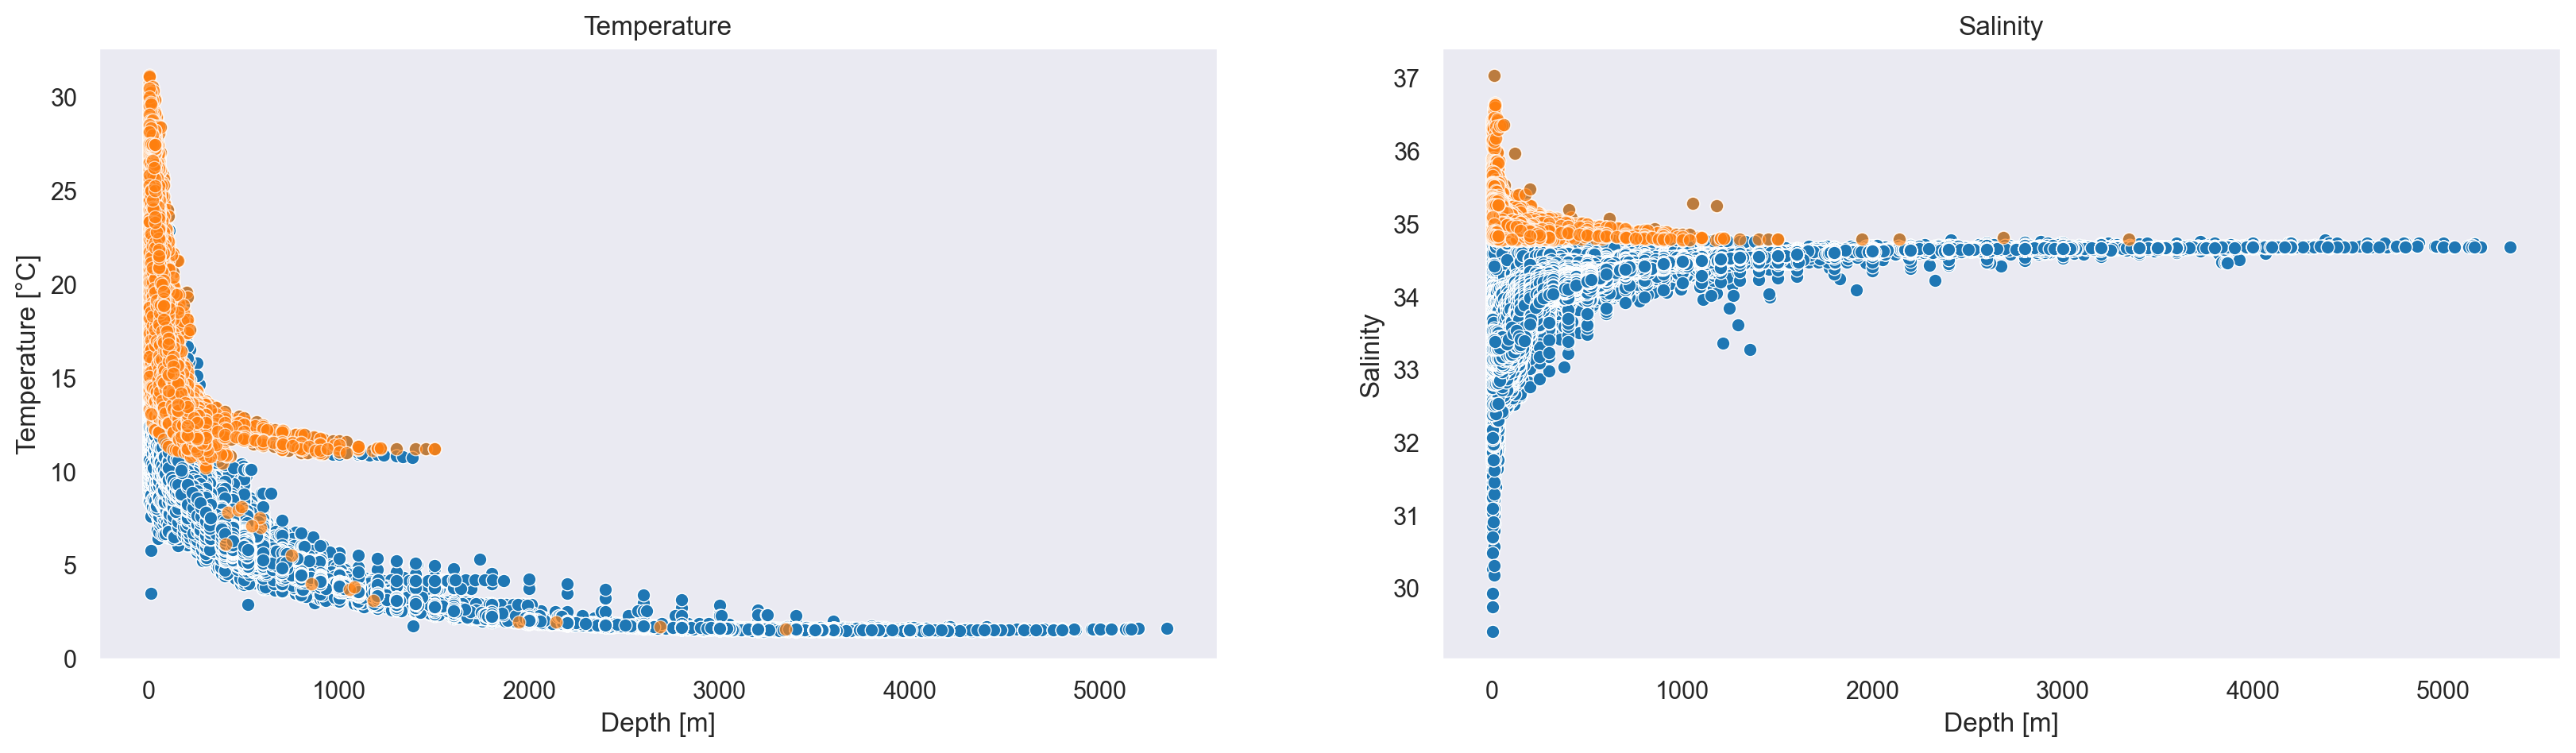

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5))
g1 = sns.scatterplot(data=bottle_df, x="Depthm", y="T_degC", ax=ax[0])
g1 = sns.scatterplot(data=bottle_hi_salt_df, x="Depthm", y="T_degC", ax=ax[0], alpha=0.7)
ax[0].set(xlabel="Depth [m]", ylabel="Temperature [°C]", title="Temperature")
ax[0].grid()

g2 = sns.scatterplot(data=bottle_df, x="Depthm", y="Salnty", ax=ax[1])
g2 = sns.scatterplot(data=bottle_hi_salt_df, x="Depthm", y="Salnty", ax=ax[1], alpha=0.7)
ax[1].set(xlabel="Depth [m]", ylabel="Salinity", title="Salinity")
ax[1].grid()

On constate bien une relation cachée. En effet, il existe 2 cas de relations entre la température et la profondeur suivant si la salinité est élevée ou non. On a une courbe température/profondeur pour les eaux peu salées, et une autre pour les eaux plus salées.

### Predictive Models

#### Splitting the Dataset

In [19]:
x_train, x_test, y_train, y_test = train_test_split(bottle_df["Depthm"], bottle_df["T_degC"], test_size=0.2)

#### Linear Regression

*   Try predicting the temperature based on depth only.

*   Evaluate the model using the RMSE and the R2 score.

*   Plot the test data and the predicted line.

In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train.values.reshape(-1, 1), y_train.values)

y_pred = model.predict(x_test.values.reshape(-1, 1))

In [21]:
from sklearn.metrics import root_mean_squared_error, r2_score

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
pprint_var(mse=rmse, r2=r2)

mse = 3.163
r2 = 0.4391


Le coefficient $R^2$ est très faible à 0.44, cela signifie que le modèle n'explique que 44% de la variance des données. Le RMSE est de 3.15, ce qui signifie que les prédictions du modèle sont en moyenne à 3.15°C de la valeur réelle, sachant que les valeur réelles varient entre 0°C et 30°C environ, on peut considérer que c'est une erreur très importante.

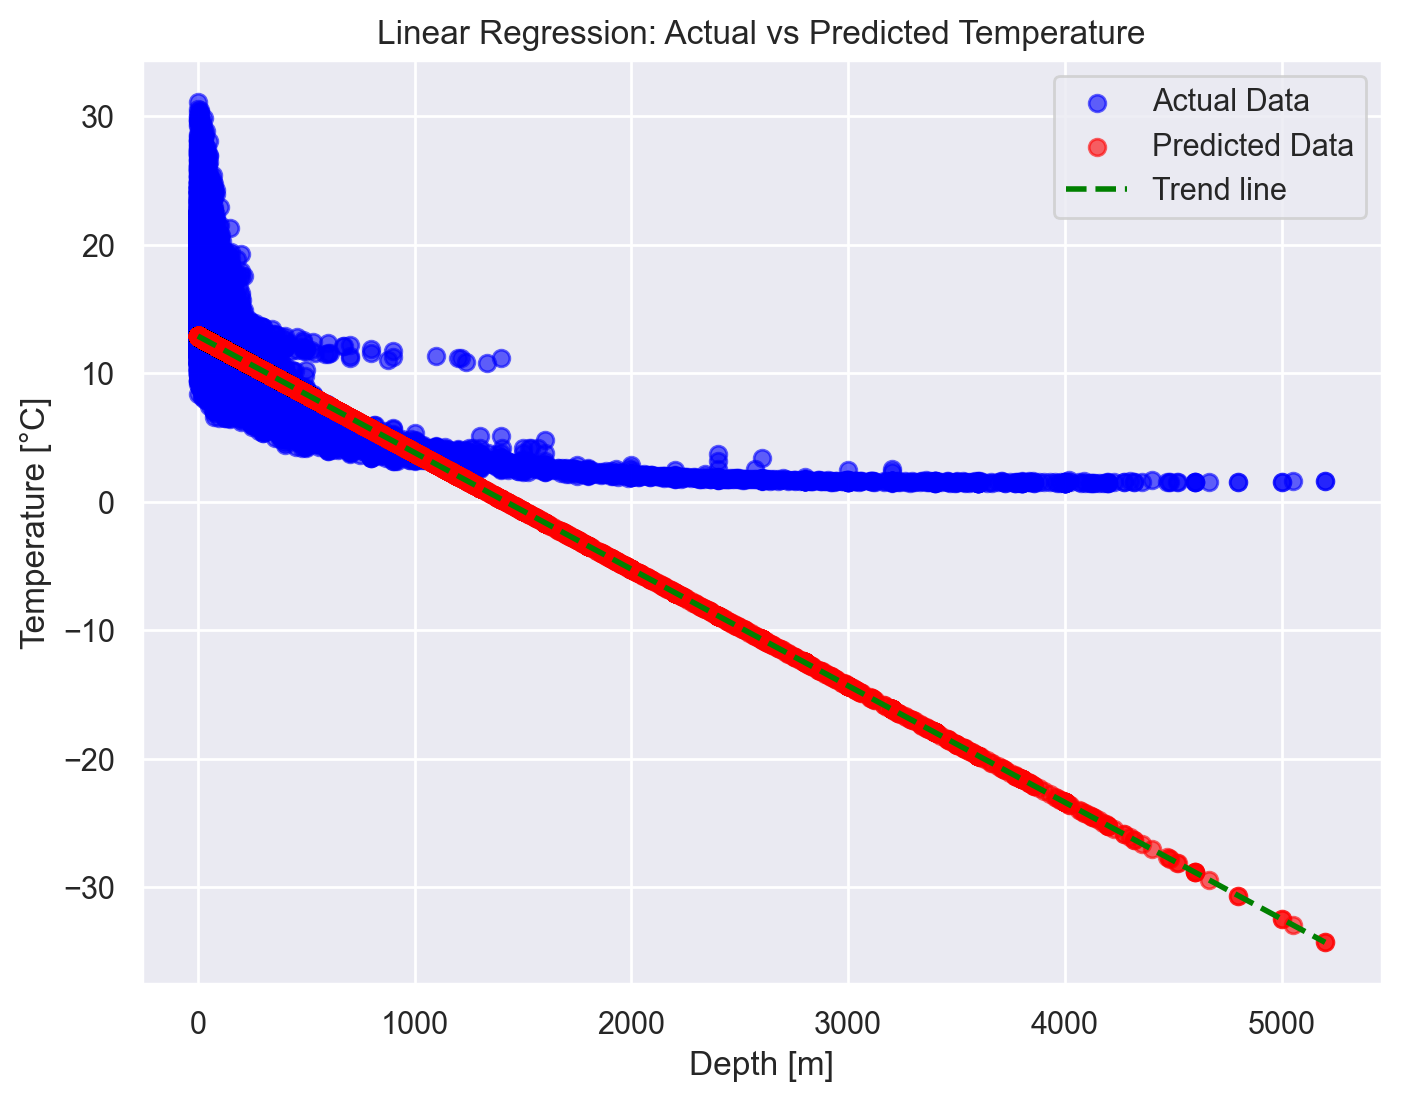

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(x_test, y_test, color="blue", label="Actual Data", alpha=0.6)
plt.scatter(x_test, y_pred, color="red", label="Predicted Data", alpha=0.6)

# Trend line
z = np.polyfit(x_test, y_pred, 1)
p = np.poly1d(z)
x_line = np.linspace(x_test.min(), x_test.max(), 100)
plt.plot(x_line, p(x_line), 'g--', linewidth=2, label='Trend line')

plt.xlabel("Depth [m]")
plt.ylabel("Temperature [°C]")
plt.title("Linear Regression: Actual vs Predicted Temperature")
plt.legend()
plt.show()

On confirme les observations faites à la suite des métriques, le modèle de régression linéaire est inadapté pour prédire la température en fonction de la profondeur uniquement, car la relation entre ces deux variables n'est pas linéaire, elle ressemble plus à une décroissance exponentielle. On remarque même que l'erreur de prédiction peut atteindre plus de 30°C à forte profondeur.

### Polynomial Regression

*   Adapt linear regression by transforming data according to basis functions

*   E.g., with a polynomial projection:
    $$\hat{y} = a_0 + a_1 x + a_2 x^2 + \cdots + a_n x^n$$

*   Note that this is still a linear model

    *   It is linear in the sense that we never multiply or divide the coefficients

    *   The one-dimensional descriptor $x$ is projected in one or more dimensions to allow modeling more complex relations between $x$ and $y$

*   Try predicting the temperature based on depth only using a polynomial regression (e.g., until `degree=5`).

*   Evaluate the model using the RMSE and the R2 score.

*   Plot the test data and the predicted curve.

In [ ]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=5)),
    ('regressor', LinearRegression())
])

pipeline.fit(x_train.values.reshape(-1, 1), y_train.values)
y_pred_poly = pipeline.predict(x_test.values.reshape(-1, 1))

Polynomial Coefficients: [ 0.00000000e+00 -6.75645074e+00  3.48222921e+00 -7.34212572e-01
  6.26630158e-02 -1.82598223e-03]
Intercept: 9.123752335455528


In [49]:
rmse_poly = root_mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)
pprint_var(rmse_poly=rmse_poly, r2_poly=r2_poly)

rmse_poly = 2.081
r2_poly = 0.7572


Avec l'étape de standardisation, on obtient un RMSE de 2.1 et un $R^2$ de 0.76, ce qui est une nette amélioration par rapport au modèle de régression linéaire simple. Le modèle polynomial est donc beaucoup plus adapté pour prédire la température en fonction de la profondeur. On pouvait s'en douter car la courbe de température en fonction de la profondeur semble exponentielle et un développement en série entière (polynôme) est une bonne approximation des fonctions exponentielles.

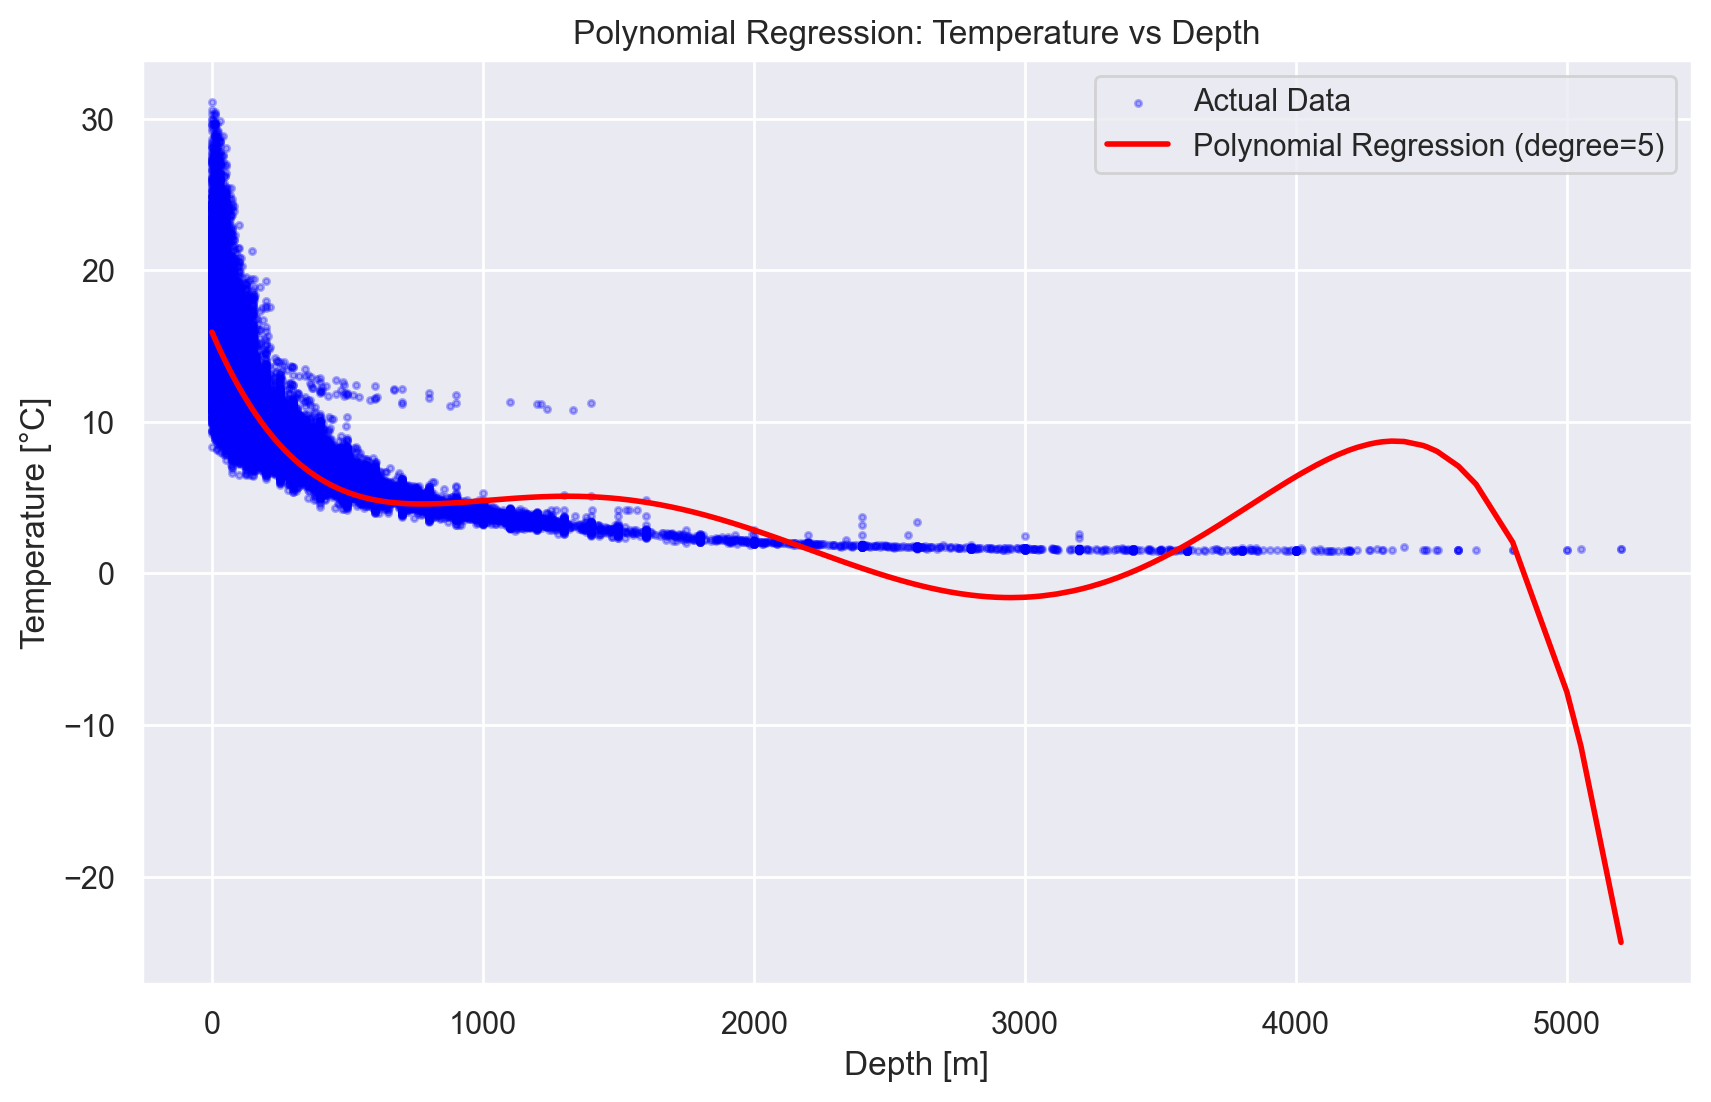

Polynomial Coefficients: [ 0.00000000e+00 -6.75645074e+00  3.48222921e+00 -7.34212572e-01
  6.26630158e-02 -1.82598223e-03]
Intercept: 9.123752335455528


In [51]:
plt.figure(figsize=(10, 6))
plt.scatter(x_test, y_test, color="blue", label="Actual Data", alpha=0.3, s=5)
# Sort the data for a smooth curve
x_test_sorted = x_test.sort_values()
y_pred_poly_sorted = pipeline.predict(x_test_sorted.values.reshape(-1, 1))

plt.plot(x_test_sorted, y_pred_poly_sorted, color="red", linewidth=2, label="Polynomial Regression (degree=5)")
plt.xlabel("Depth [m]")
plt.ylabel("Temperature [°C]")
plt.title("Polynomial Regression: Temperature vs Depth")
plt.legend()
plt.show()

coefficients = pipeline.named_steps['regressor'].coef_
intercept = pipeline.named_steps['regressor'].intercept_
print("Polynomial Coefficients:", coefficients)
print("Intercept:", intercept)

La courbe de prédiction suit de près les données aux profondeurs pour lesquelles il y a beaucoup de points, ce qui explique la bonne performance du modèle. Cependant, à forte profondeur, où les données sont plus rares, la prédiction s'écarte fortement des valeurs réelles; cela n'est pas visible dans les métriques car ce sont des moyennes sur l'ensemble du jeu de données et que ces erreurs arrivent pour un faible nombre de points.

#### Multiple Linear Regression

*   Perform the linear regression again using the set of 5 features available instead of just one.

*   Evaluate the performance of the regression in terms of MSE and $R^2$.

*   Identify the features that seem the most significant for this regression, by observing the value of their respective parameter ($a_j$ via `model.coef_`).

*   Comment succinctly.

<span style="color:red">Implement your solution below</span>

### Standardization and PCA

Apply standardization and PCA to the dataset and repeat the regression and the evaluations.

The goal is to see if the performance of the regression improves and if the features that are the most significant change.

Try to analyze the results and comment on your observations (possibly with tables and plots similar to those in the PCA notebook).

<span style="color:red">Implement your solution below</span>

---